In [1]:
# %% [markdown]
# ## 1. Imports & Constants
# Load required libraries and define input/output paths.

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MERGED_CSV = "../artifacts/tests/combined.csv"
OUTDIR = "../artifacts/figures"

In [2]:
# Full model name → Short name mapping
model_name_map = {
    "BAAI__bge-base-en": "BAAI_bgeB",
    "BAAI__bge-base-en-v1.5": "BAAI_bgeB_v1.5",
    "BAAI__bge-large-en": "BAAI_bgeL",
    "BAAI__bge-large-en-v1.5": "BAAI_bgeL_v1.5",
    "BAAI__bge-small-en": "BAAI_bgeS",
    "BAAI__bge-small-en-v1.5": "BAAI_bgeS_v1.5",
    "BAAI__bge-m3": "BAAI_bgeM3",
    "DeepChem__ChemBERTa-77M-MTR": "DC_ChemBERTa",
    "facebook__contriever": "FB_contriever",
    "facebook__contriever-msmarco": "FB_contrieverMS",
    "google-bert__bert-base-uncased": "GGL_BERTbU",
    "intfloat__e5-small": "Intf_e5S",
    "intfloat__e5-small-v2": "Intf_e5S_v2",
    "intfloat__e5-base": "Intf_e5B",
    "intfloat__e5-base-v2": "Intf_e5B_v2",
    "intfloat__e5-large": "Intf_e5L",
    "intfloat__e5-large-v2": "Intf_e5L_v2",
    "intfloat__multilingual-e5-base": "Intf_mE5B",
    "intfloat__multilingual-e5-large": "Intf_mE5L",
    "intfloat__multilingual-e5-small": "Intf_mE5S",
    "jinaai__jina-embeddings-v2-base-en": "Jina_v2B",
    "jinaai__jina-embeddings-v2-small-en": "Jina_v2S",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext": "MS_BiomedBERT_af",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext": "MS_PubMedBERT_af",
    "microsoft__MiniLM-L12-H384-uncased": "MS_MiniLM384",
    "microsoft__mpnet-base": "MS_MPNetB",
    "m3rg-iitd__matscibert": "IITD_MatSci",
    "nomic-ai__nomic-bert-2048": "Nomic_BERT2048",
    "nomic-ai__nomic-embed-text-v1": "Nomic_text_v1",
    "nomic-ai__nomic-embed-text-v1.5": "Nomic_text_v1.5",
    "nomic-ai__nomic-embed-text-v2-moe":"Nomic_text_v2",
    "describeai__gemini": "Desc_Gemini",
    "hkunlp__instructor-xl": "HKU_InstructXL",
    "allenai__scibert_scivocab_uncased": "AI_SciBERT",
    "allenai__specter": "AI_Specter",
    "recobo__chemical-bert-uncased": "Rec_ChemBERT",
    "sentence-transformers__all-mpnet-base-v2": "Sent_allMPNetB_v2",
    "sentence-transformers__all-MiniLM-L6-v2": "Sent_MiniLM6_v2",
    "sentence-transformers__all-MiniLM-L12-v2": "Sent_MiniLM12_v2",
    "sentence-transformers__bert-base-nli-mean-tokens": "Sent_BERTnli",
    "sentence-transformers__gtr-t5-base": "Sent_gtrT5_B",
    "sentence-transformers__gtr-t5-large": "Sent_gtrT5_L",
    "sentence-transformers__gtr-t5-xl": "Sent_gtrT5_XL",
    "sentence-transformers__multi-qa-mpnet-base-dot-v1": "Sent_MQA_MPNetB",
    "sentence-transformers__paraphrase-multilingual-MiniLM-L12-v2": "Sent_paraMiniLM12",
    "multi-qa-mpnet-base-dot-v1": "MQA_MPNetB",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract" : "MS_PubMedBERT_a",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract" : "MS_BiomedBERT_a",
    "sentence-transformers__paraphrase-multilingual-mpnet-base-v2" : "Sent_paraMPNetB_v2",
}


def _norm_model_key(s: str) -> str:
    if s is None:
        return ""
    # unify separators so mapping keys match
    return str(s).replace("/", "__").strip()


In [3]:
# import pandas as pd



# def merge_runs_by_outdir(csv_path: str,
#                          tz: str | None = "Europe/Berlin",
#                          save_path: str | None = "merged_runs.csv") -> pd.DataFrame:
#     """
#     Read the CSV of stage runs and merge triplets (stage4/5/6) by `outdir`.
#     - Keeps per-stage started/ended/duration/status.
#     - Keeps shared metadata (model, revision, chunker, size, overlap) once.
#     - Adds `duration_sum_s` = sum of available stage durations.
#     - Timezone-aware parsing from the 'Z' timestamps; converts to `tz` if given.

#     Returns the merged DataFrame and (optionally) writes it to CSV.
#     """

#     # --- Read & parse ---
#     df = pd.read_csv(
#         csv_path,
#         dtype={
#             "duration_s": "Int64",
#             "status": "Int64",
#             "stage": "string",
#             "model": "string",
#             "revision": "string",
#             "chunker": "string",
#             "size": "Int64",
#             "overlap": "Int64",
#             "outdir": "string",
#         }
#     )

#     # --- in merge_runs_by_outdir(...) after reading df ---
#     df["model_short"] = (
#         df["model"].astype("string")
#         .map(lambda x: model_name_map.get(_norm_model_key(x), x))
#         .astype("string")
#     )

#     # Parse times as UTC and optionally convert to desired tz
#     for col in ["started_at", "ended_at"]:
#         dt = pd.to_datetime(df[col], utc=True, errors="coerce")
#         if tz:
#             dt = dt.dt.tz_convert(tz)
#         df[col] = dt

#     # --- Pivot per-stage fields ---
#     # We’ll pivot the per-stage columns to wide format so each stage gets its own set of columns
#     per_stage_cols = ["started_at", "ended_at", "duration_s", "status"]
#     wide = (
#         df.set_index(["outdir", "stage"])[per_stage_cols]
#           .unstack("stage")  # columns become a MultiIndex (field, stage)
#     )

#     # Flatten MultiIndex column names: e.g., ('duration_s','stage4') -> 'duration_s_stage4'
#     wide.columns = [f"{field}_{stage}" for field, stage in wide.columns]

#     # --- Bring along shared metadata (assumed identical within an outdir) ---
#     shared_cols = ["model", "model_short", "revision", "chunker", "size", "overlap"]
#     meta = (
#         df.drop_duplicates(subset=["outdir"])[["outdir"] + shared_cols]
#           .set_index("outdir")
#     )

#     merged = meta.join(wide, how="left").reset_index()

#     # --- Add total duration across available stages ---
#     duration_cols = [c for c in merged.columns if c.startswith("duration_s_stage")]
#     merged["duration_sum_s"] = merged[duration_cols].sum(axis=1, skipna=True).astype("Int64")

#     # Optional: sort columns nicely
#     def order_cols(cols):
#         # Put keys & shared first, then stage4/5/6 blocks in order, then total
#         base = ["outdir"] + shared_cols
#         stages = ["stage4", "stage5", "stage6"]
#         per = ["started_at", "ended_at", "duration_s", "status"]

#         ordered = base[:]
#         for st in stages:
#             for p in per:
#                 name = f"{p}_{st}"
#                 if name in cols:
#                     ordered.append(name)
#         if "duration_sum_s" in cols:
#             ordered.append("duration_sum_s")
#         # any leftovers
#         ordered += [c for c in cols if c not in ordered]
#         return ordered

#     merged = merged[order_cols(list(merged.columns))]

#     # Save if requested
#     if save_path:
#         # Use index=False to keep the file clean
#         merged.to_csv(save_path, index=False)

#     return merged


# # --- Example usage ---
# if __name__ == "__main__":
#     merged_df = merge_runs_by_outdir(csv_path, tz="Europe/Berlin", save_path=MERGED_CSV)
#     print(merged_df.head())
#     # If you want to verify sums:
#     cols = [c for c in merged_df.columns if c.startswith("duration_s_stage")]
#     check = merged_df[["outdir", "duration_sum_s"] + cols]
#     print(check.head())


In [4]:
def load_merged(path=MERGED_CSV, tz="Europe/Berlin"):
    df = pd.read_csv(path, dtype={"size":"Int64","overlap":"Int64","model":"string","model_short":"string"})
    if "model_short" not in df.columns or df["model_short"].equals(df["model"]):
        df["model_short"] = (
            df["model"].astype("string")
            .map(lambda x: model_name_map.get(_norm_model_key(x), x))
            .astype("string")
        )
    for st in ("stage4","stage5","stage6"):
        for col in ("started_at","ended_at"):
            c = f"{col}_{st}"
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], utc=True, errors="coerce").dt.tz_convert(tz)
    for st in ("stage4","stage5","stage6"):
        c = f"duration_s_{st}"
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "duration_sum_s" in df.columns:
        df["duration_sum_s"] = pd.to_numeric(df["duration_sum_s"], errors="coerce")
    return df

df = load_merged()

# Use short names if present
MODEL_COL = "model_short" if "model_short" in df.columns else "model"


In [5]:
# %% [markdown]
# ## 3. Ensure output directory exists

# %%
def ensure_outdir(path=OUTDIR):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    return path

ensure_outdir()
print("Output directory ready:", OUTDIR)


Output directory ready: ../artifacts/figures


In [6]:
# %% [markdown]
# ## 4. Summary Statistics

# %%
# Basic summary tables and aggregates
cols = [MODEL_COL,"chunker","size","overlap","duration_sum_s"]
cols = [c for c in cols if c in df.columns]

print("=== Summary (first 10 rows) ===")
display(df[cols].head(10))

by_keys = [k for k in (MODEL_COL,"chunker","size","overlap") if k in df.columns]
if by_keys:
    agg = (df.groupby(by_keys, dropna=False)["duration_sum_s"]
             .agg(["count","mean","median","min","max"])
             .sort_values("mean"))
    print("\n=== Aggregates by keys ===")
    display(agg.head(20))

present = {st: f"duration_s_{st}" in df.columns and df[f"duration_s_{st}"].notna().any()
           for st in ("stage4","stage5","stage6")}
print("\nStage columns present:", present)


=== Summary (first 10 rows) ===


,model_short,size,duration_sum_s
0,Intf_e5L_v2,384,142
1,Intf_e5L_v2,512,125
2,Intf_e5L_v2,448,138
3,Intf_e5L_v2,384,145
4,Intf_e5L_v2,512,132
5,Intf_e5L_v2,448,164
6,Intf_e5L_v2,512,158
7,Intf_e5L_v2,512,617
8,Intf_e5L_v2,448,170
9,Intf_e5L_v2,448,140



=== Aggregates by keys ===


count        mean  median  min  max
model_short    size                                     
Intf_e5S       512       5   99.000000    77.0   48  169
               448      25   99.400000    77.0   47  165
               384      25  100.360000    78.0   48  166
BAAI_bgeS_v1.5 512       5  100.600000    73.0   50  174
Intf_e5S       320      25  102.440000    81.0   47  170
               256      25  105.280000    84.0   47  175
BAAI_bgeS_v1.5 448      25  106.040000    81.0   49  179
               384      25  106.080000    80.0   50  179
Intf_mE5S      512       5  107.200000    82.0   55  179
Intf_e5S       192      20  108.200000    88.5   47  179
BAAI_bgeS_v1.5 320      25  109.080000    84.0   50  183
               256      25  112.080000    89.0   50  187
Intf_mE5S      448      25  112.280000    89.0   56  183
               384      25  113.480000    90.0   56  185
Intf_e5S       128      15  114.733333    99.0   48  188
BAAI_bgeS_v1.5 192      20  114.750000    90.5   50  192
Intf_mE5S      320      25  115.640000    94.0   55  188
               256      25  119.440000    97.0   55  194
BAAI_bgeS_v1.5 128      15  121.666667   102.0   52  202
Intf_mE5S      192      20  123.350000   104.0   54  197


Stage columns present: {'stage4': np.True_, 'stage5': np.True_, 'stage6': np.True_}


/tmp/ipykernel_44665/4268066172.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_models = cm.get_cmap("tab20", len(unique_models))
/tmp/ipykernel_44665/4268066172.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_chunkers = cm.get_cmap("tab20", len(unique_chunkers))


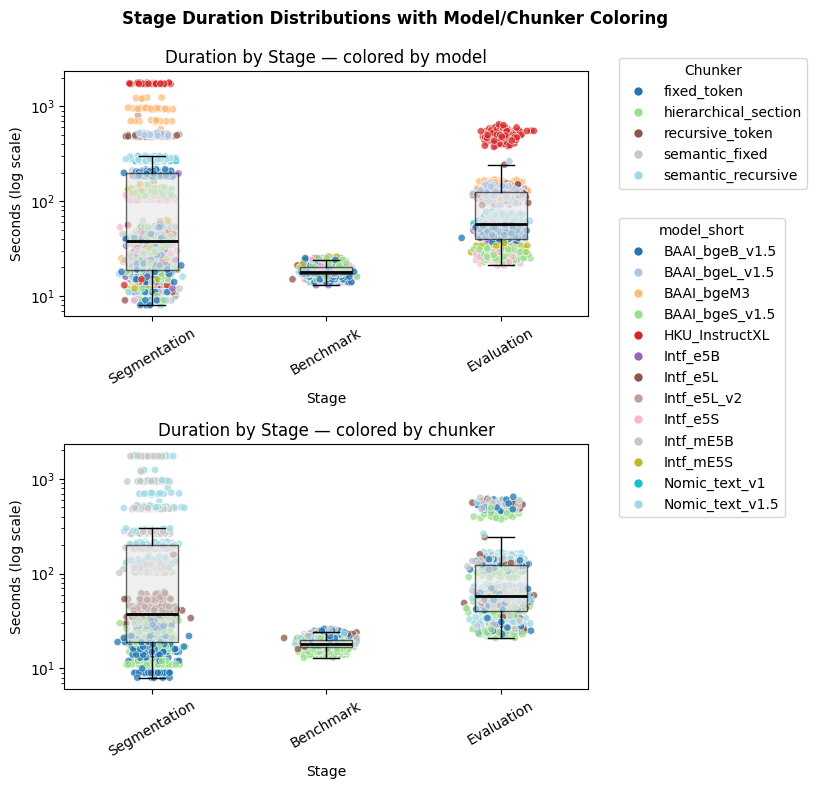

✅ Saved: ../artifacts/figures/boxplot_stage_durations_2subplots_aligned_legends.png


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

OUTDIR = "../artifacts/figures"
os.makedirs(OUTDIR, exist_ok=True)

# --- gather available stage columns ---
stage_cols = [
    s for s in ("stage4", "stage5", "stage6")
    if f"duration_s_{s}" in df.columns and df[f"duration_s_{s}"].notna().any()
]
if not stage_cols:
    raise ValueError("No stage duration columns found (expected duration_s_stage4/5/6).")

# --- build a long dataframe: (stage, duration, model, chunker) ---
rows = []
for st in stage_cols:
    col = f"duration_s_{st}"
    sub = df[[col, MODEL_COL, "chunker_y"]].copy()
    sub = sub.rename(columns={col: "duration"})
    sub["stage"] = st
    rows.append(sub.dropna(subset=["duration"]))
long_df = pd.concat(rows, ignore_index=True)

stages_order = stage_cols
stage_labels = {
    "stage4": "Segmentation",
    "stage5": "Benchmark",
    "stage6": "Evaluation",
}
stage_descriptions = {
    "stage4": "Segmentation: Document segmentation",
    "stage5": "Benchmark: Local benchmark construction",
    "stage6": "Evaluation: Retrieval evaluation",
}

def stage_data():
    return [long_df.loc[long_df["stage"] == st, "duration"].values for st in stages_order]

# --- colors for models and chunkers ---
unique_models = sorted(long_df[MODEL_COL].astype(str).dropna().unique())
cmap_models = cm.get_cmap("tab20", len(unique_models))
color_by_model = {m: cmap_models(i) for i, m in enumerate(unique_models)}

unique_chunkers = sorted(long_df["chunker_y"].astype(str).dropna().unique())
cmap_chunkers = cm.get_cmap("tab20", len(unique_chunkers))
color_by_chunker = {c: cmap_chunkers(i) for i, c in enumerate(unique_chunkers)}

# --- plotting ---
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True)

def draw_box_with_scatter(ax, color_map, by_col, title_suffix):
    data = stage_data()
    bp = ax.boxplot(data, tick_labels=[stage_labels.get(st, st) for st in stages_order], showfliers=False, patch_artist=True)
    for b in bp["boxes"]:
        b.set(facecolor="#e6e6e6", alpha=0.6)
    for m in bp["medians"]:
        m.set(color="#000", linewidth=2)

    for i, st in enumerate(stages_order, start=1):
        sub = long_df[long_df["stage"] == st]
        x = np.random.normal(i, 0.06, size=len(sub))
        colors = [color_map.get(str(v), "#555555") for v in sub[by_col].astype(str)]
        ax.scatter(x, sub["duration"].values, s=28, alpha=0.75,
                   c=colors, edgecolor="white", linewidth=0.5)

    ax.set_title(f"Duration by Stage — colored by {title_suffix}")
    ax.set_xlabel("Stage")
    ax.set_ylabel("Seconds (log scale)")
    ax.tick_params(axis="x", rotation=30)
    ax.set_yscale("log")

# Left: colored by model
draw_box_with_scatter(axes[0], color_by_model, MODEL_COL, "model")
# Right: colored by chunker
draw_box_with_scatter(axes[1], color_by_chunker, "chunker_y", "chunker")

# --- figure-level legends (aligned) ---
handles_models = [
    plt.Line2D([0], [0], marker="o", color="w", label=m,
               markerfacecolor=c, markersize=7)
    for m, c in color_by_model.items()
]
handles_chunkers = [
    plt.Line2D([0], [0], marker="o", color="w", label=c,
               markerfacecolor=col, markersize=7)
    for c, col in color_by_chunker.items()
]

# Leave space for legends on right
plt.tight_layout(rect=[0, 0, 0.76, 0.95])

# 🎯 aligned legends – same x, different y
fig.legend(
    handles=handles_chunkers,
    title="Chunker",
    loc="upper left",
    bbox_to_anchor=(0.78, 0.92),
    borderaxespad=0.0
)

fig.legend(
    handles=handles_models,
    title=MODEL_COL,
    loc="upper left",
    bbox_to_anchor=(0.78, 0.72),
    borderaxespad=0.0
)

handles_stages = [
    plt.Line2D([], [], linestyle="none", label=stage_descriptions[st])
    for st in stages_order
]


plt.suptitle("Stage Duration Distributions with Model/Chunker Coloring", fontweight="bold", y=0.98)

out_path = os.path.join(OUTDIR, "boxplot_stage_durations_2subplots_aligned_legends.png")
plt.savefig(out_path, dpi=150)
plt.show()
print("✅ Saved:", out_path)


/tmp/ipykernel_44665/1096158522.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups_sorted, showfliers=False, patch_artist=True)
/tmp/ipykernel_44665/1096158522.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups_sorted, showfliers=False, patch_artist=True)
/tmp/ipykernel_44665/1096158522.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups_sorted, showfliers=False, patch_artist=True)
/tmp/ipykernel_44665/1096158522.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick

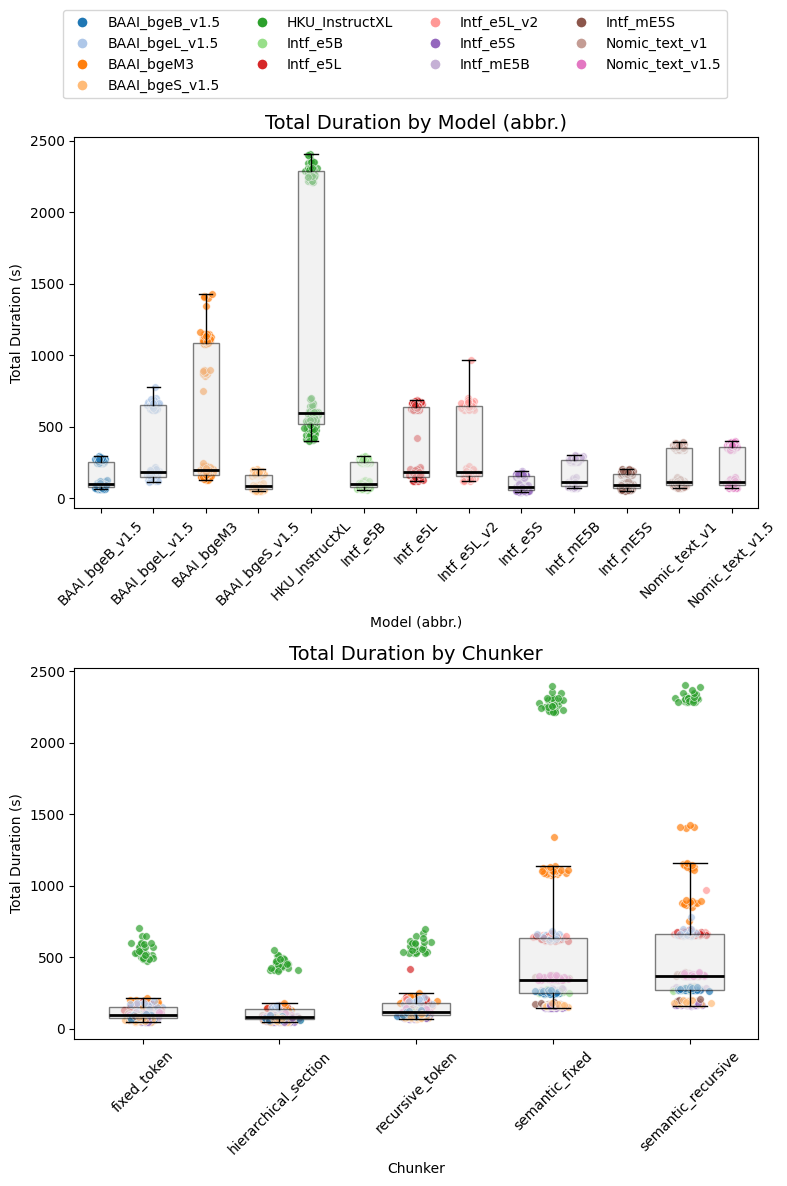

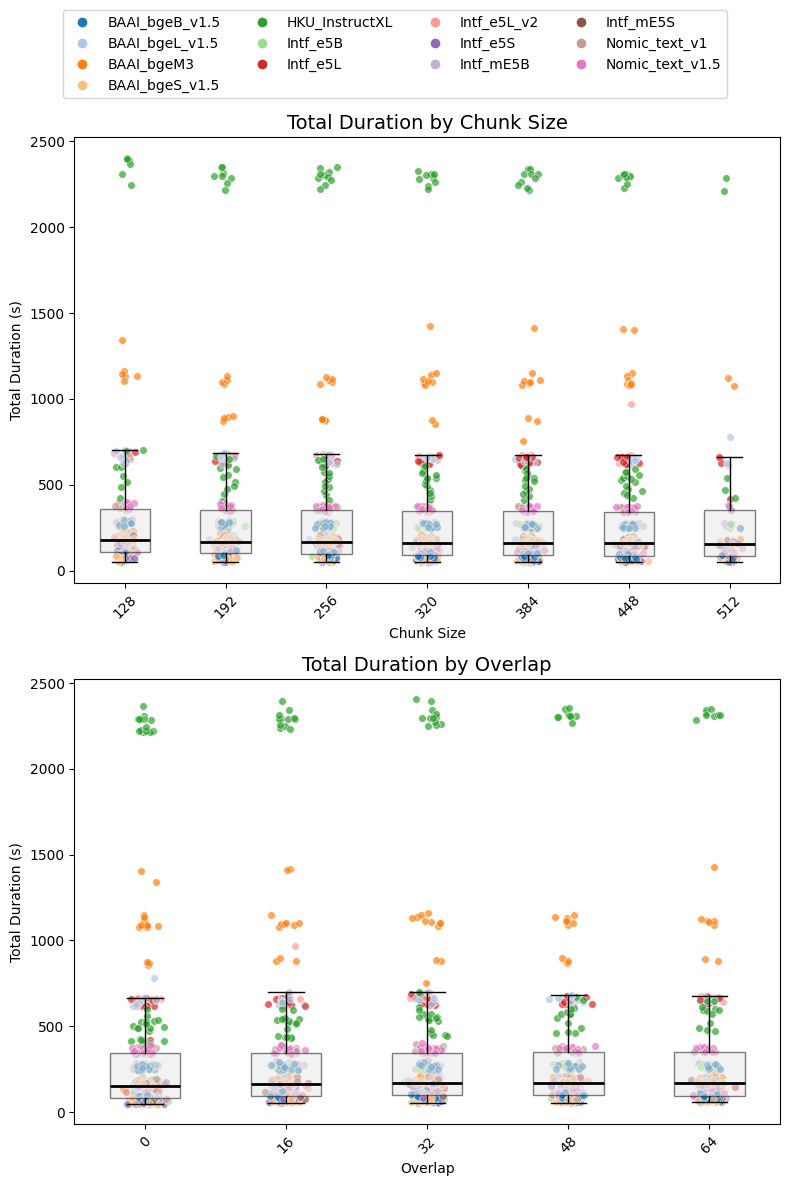

✅ Saved figures: ../artifacts/figures/boxplots_2x2_colored_by_model_1.png and ../artifacts/figures/boxplots_2x2_colored_by_model_2.png


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
OUTDIR = "../artifacts/figures"
os.makedirs(OUTDIR, exist_ok=True)
MODEL_COL = "model_short" if "model_short" in df.columns else "model"

fig1, axes1 = plt.subplots(2, 1, figsize=(8, 12))
fig2, axes2 = plt.subplots(2, 1, figsize=(8, 12))

# 🎨 Create a color map for models
if MODEL_COL in df.columns:
    unique_models = sorted(df[MODEL_COL].dropna().astype(str).unique())
    cmap = mpl.colormaps.get_cmap("tab20")
    color_map = {model: cmap(i) for i, model in enumerate(unique_models)}
else:
    color_map = {}


def add_boxplot_with_colored_scatter(ax, df, group_col, value_col, title, xlabel, model_col=MODEL_COL):
    if {group_col, value_col, model_col}.issubset(df.columns):
        clean_df = df.dropna(subset=[group_col, value_col, model_col]).copy()
        clean_df[value_col] = clean_df[value_col].astype(float)
        clean_df[group_col] = clean_df[group_col]
        clean_df[model_col] = clean_df[model_col].astype(str)

        grouped = clean_df.groupby(group_col)[value_col]
        groups_sorted = sorted(grouped.groups.keys())
        data = [grouped.get_group(g).values for g in groups_sorted]

        bp = ax.boxplot(data, labels=groups_sorted, showfliers=False, patch_artist=True)
        for box in bp['boxes']:
            box.set(facecolor="#e6e6e6", alpha=0.5)
        for median in bp['medians']:
            median.set(color="#000", linewidth=2)

        for i, group_val in enumerate(groups_sorted, start=1):
            subset = clean_df[clean_df[group_col] == group_val]
            for _, row in subset.iterrows():
                x = np.random.normal(i, 0.05)
                color = color_map.get(row[model_col], "#555555")
                ax.scatter(x, row[value_col], color=color, alpha=0.7, s=30, edgecolor="white", linewidth=0.5)

        ax.set_title(title, fontsize=14)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Total Duration (s)")
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.text(0.5, 0.5, f"Missing '{group_col}', '{model_col}', or '{value_col}'", ha='center', va='center')


# ---------- 1. Chunk Size ----------
add_boxplot_with_colored_scatter(
    axes2[0], df, "size", "duration_sum_s",
    title="Total Duration by Chunk Size",
    xlabel="Chunk Size"
)

# ---------- 2. Overlap ----------
add_boxplot_with_colored_scatter(
    axes2[1], df, "overlap_y", "duration_sum_s",
    title="Total Duration by Overlap",
    xlabel="Overlap"
)

# ---------- 3. Model ----------
add_boxplot_with_colored_scatter(
    axes1[0], df, MODEL_COL, "duration_sum_s",
    title="Total Duration by Model (abbr.)",
    xlabel="Model (abbr.)"
)


# ---------- 4. Chunker ----------
add_boxplot_with_colored_scatter(
    axes1[1], df, "chunker_y", "duration_sum_s",
    title="Total Duration by Chunker",
    xlabel="Chunker"
)

# 🎨 Add legend for models
handles = [plt.Line2D([0], [0], marker='o', color='w', label=m, 
                      markerfacecolor=c, markersize=8) for m, c in color_map.items()]
for fig in (fig1, fig2):
    fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.99))


# ---------- Final layout ----------
# plt.suptitle("Distribution of Total Duration by Parameters (Colored by Model)", fontsize=16, fontweight='bold')
fig1.tight_layout(rect=[0, 0, 1, 0.91])
fig2.tight_layout(rect=[0, 0, 1, 0.91])

out_path1 = os.path.join(OUTDIR, "boxplots_2x2_colored_by_model_1.png")
out_path2 = os.path.join(OUTDIR, "boxplots_2x2_colored_by_model_2.png")
fig1.savefig(out_path1, dpi=150)
fig2.savefig(out_path2, dpi=150)
plt.show()

print("✅ Saved figures:", out_path1, "and", out_path2)


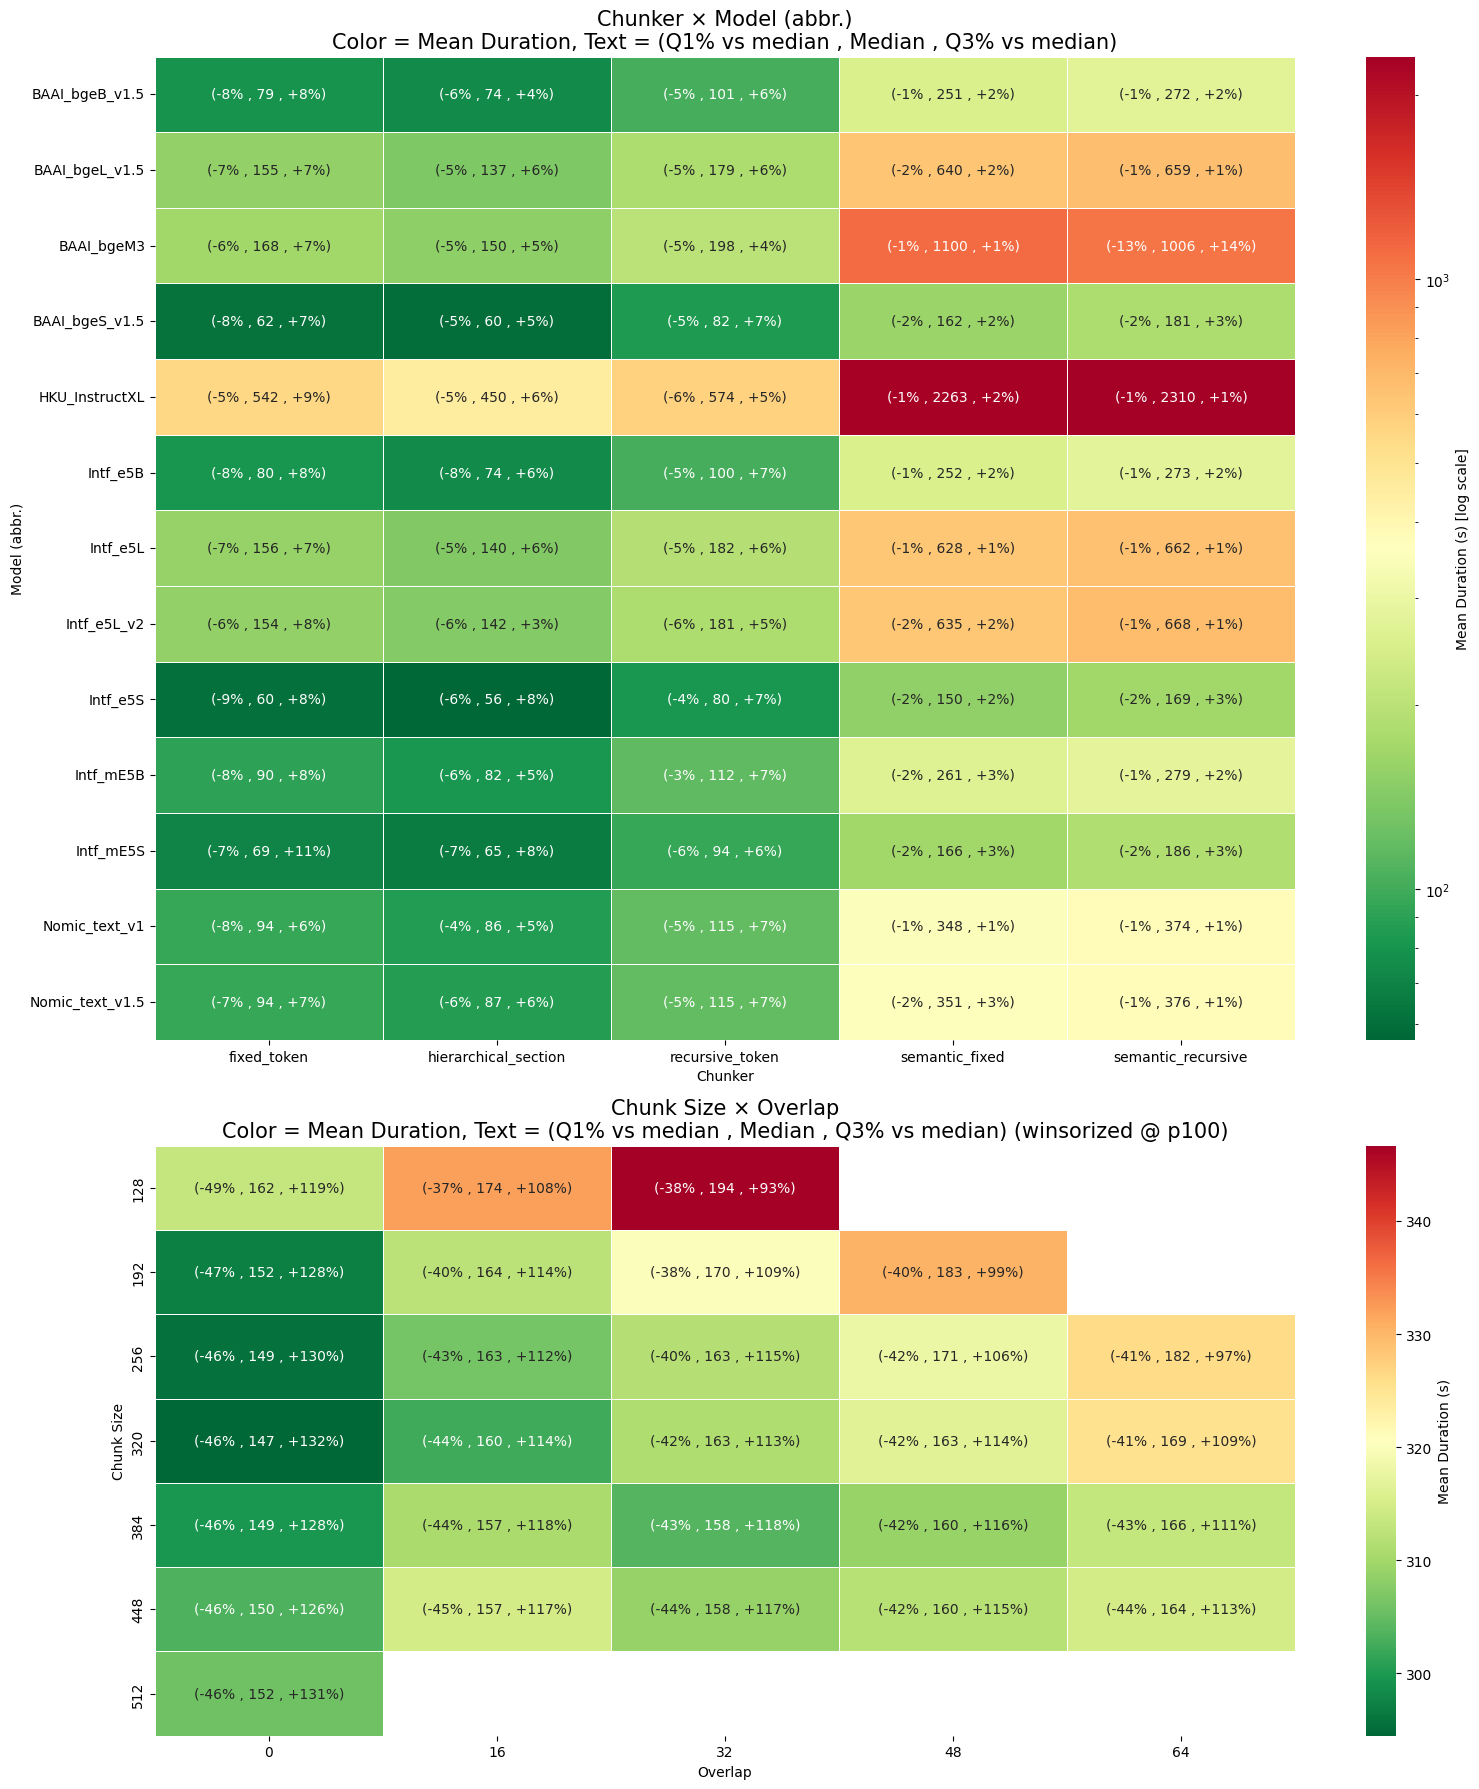

✅ Saved 2-row combined heatmap: ../artifacts/figures/combined_heatmap_2rows_winsorize.png


In [9]:
# %% [markdown]
# ## Combined Heatmap: Chunker × Model  AND  Chunk Size × Overlap (2 rows)
# - Top: Chunker × Model
# - Bottom: Chunk Size × Overlap
# - Color = Mean Duration, Text = (Q1% vs median , Median , Q3% vs median)

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors 
OUTDIR = "../artifacts/figures"
os.makedirs(OUTDIR, exist_ok=True)

mode  = "winsorize"   # "winsorize" or "mask"
pclip = 100            # percentile for winsorize/mask
cmap  = "RdYlGn_r"    # green -> red

fig, axes = plt.subplots(2, 1, figsize=(16, 18), gridspec_kw={'height_ratios': [2, 1.2]})  # <-- 2 rows, 1 column

# =============================
# 🔹 1️⃣ Chunker × Model Heatmap (TOP)
# =============================
required1 = {"chunker_y", MODEL_COL, "duration_sum_s"}
if required1.issubset(df.columns):
    base1 = (
        df.dropna(subset=["chunker_y", MODEL_COL, "duration_sum_s"])
          .assign(chunker=df["chunker_y"].astype(str),
                  model=df[MODEL_COL].astype(str),
                  duration_sum_s=df["duration_sum_s"].astype(float))
    )

    mean_pivot1 = base1.groupby([MODEL_COL,"chunker_y"])["duration_sum_s"].mean().unstack(fill_value=np.nan)
    q1_pivot1   = base1.groupby([MODEL_COL,"chunker_y"])["duration_sum_s"].quantile(0.25).unstack(fill_value=np.nan)
    q2_pivot1   = base1.groupby([MODEL_COL,"chunker_y"])["duration_sum_s"].quantile(0.50).unstack(fill_value=np.nan)
    q3_pivot1   = base1.groupby([MODEL_COL,"chunker_y"])["duration_sum_s"].quantile(0.75).unstack(fill_value=np.nan)

    annot1 = np.empty(mean_pivot1.shape, dtype=object)
    for i in range(mean_pivot1.shape[0]):
        for j in range(mean_pivot1.shape[1]):
            median_val = q2_pivot1.values[i, j]
            q1_val = q1_pivot1.values[i, j]
            q3_val = q3_pivot1.values[i, j]
            if np.isnan(median_val):
                annot1[i, j] = ""
            else:
                q1_pct = ((q1_val - median_val) / median_val) * 100 if median_val != 0 else np.nan
                q3_pct = ((q3_val - median_val) / median_val) * 100 if median_val != 0 else np.nan
                annot1[i, j] = f"({q1_pct:+.0f}% , {median_val:.0f} , {q3_pct:+.0f}%)"

    M1 = mean_pivot1.values.astype(float)
    if mode == "winsorize":
        hi = np.nanpercentile(M1, pclip)
        display_mat1 = mean_pivot1.clip(upper=hi)
        sns.heatmap(display_mat1, cmap=cmap, norm=mcolors.LogNorm(vmin=max(display_mat1.min().min(), 1e-2), vmax=display_mat1.max().max()),linewidths=0.5, annot=annot1, fmt="", annot_kws={"fontsize":10},
                    cbar_kws={"label": "Mean Duration (s) [log scale]"}, ax=axes[0])
        title_suffix1 = f" (winsorized @ p{pclip})"
    elif mode == "mask":
        hi = np.nanpercentile(M1, pclip)
        mask1 = mean_pivot1.values > hi
        annot_masked1 = np.where(mask1, "", annot1)
        sns.heatmap(mean_pivot1, mask=mask1, cmap=cmap, norm=mcolors.LogNorm(vmin=max(display_mat1.min().min(), 1e-2), vmax=display_mat1.max().max()), linewidths=0.5, annot=annot_masked1, fmt="",
                    annot_kws={"fontsize":10}, cbar_kws={"label": "Mean Duration (s) [log scale]"}, ax=axes[0])
        title_suffix1 = f" (values > p{pclip} hidden)"
    else:
        sns.heatmap(mean_pivot1, cmap=cmap, norm=mcolors.LogNorm(vmin=max(display_mat1.min().min(), 1e-2), vmax=display_mat1.max().max()), linewidths=0.5, annot=annot1, fmt="", annot_kws={"fontsize":10},
                    cbar_kws={"label": "Mean Duration (s) [log scale]"}, ax=axes[0])
        title_suffix1 = ""

    axes[0].set_title("Chunker × Model (abbr.)\nColor = Mean Duration, Text = (Q1% vs median , Median , Q3% vs median)", fontsize=15)
    axes[0].set_ylabel("Model (abbr.)")
    axes[0].set_xlabel("Chunker")

# ================================
# 🔹 2️⃣ Chunk Size × Overlap Heatmap (BOTTOM)
# ================================
required2 = {"size", "overlap_y", "duration_sum_s"}
if required2.issubset(df.columns):
    base2 = (
        df.dropna(subset=["size", "overlap_y", "duration_sum_s"])
          .assign(size=pd.to_numeric(df["size"], errors="coerce"),
                  overlap=pd.to_numeric(df["overlap_y"], errors="coerce"),
                  duration_sum_s=pd.to_numeric(df["duration_sum_s"], errors="coerce"))
          .dropna(subset=["size","overlap_y","duration_sum_s"])
    )

    mean_pivot2 = base2.groupby(["size","overlap_y"])["duration_sum_s"].mean().unstack(fill_value=np.nan)
    q1_pivot2   = base2.groupby(["size","overlap_y"])["duration_sum_s"].quantile(0.25).unstack(fill_value=np.nan)
    q2_pivot2   = base2.groupby(["size","overlap_y"])["duration_sum_s"].quantile(0.50).unstack(fill_value=np.nan)
    q3_pivot2   = base2.groupby(["size","overlap_y"])["duration_sum_s"].quantile(0.75).unstack(fill_value=np.nan)

    mean_pivot2 = mean_pivot2.sort_index(axis=0).sort_index(axis=1)
    q1_pivot2   = q1_pivot2.reindex_like(mean_pivot2)
    q2_pivot2   = q2_pivot2.reindex_like(mean_pivot2)
    q3_pivot2   = q3_pivot2.reindex_like(mean_pivot2)


    

    annot2 = np.empty(mean_pivot2.shape, dtype=object)
    for i in range(mean_pivot2.shape[0]):
        for j in range(mean_pivot2.shape[1]):
            median_val = q2_pivot2.values[i, j]
            q1_val = q1_pivot2.values[i, j]
            q3_val = q3_pivot2.values[i, j]
            if np.isnan(median_val):
                annot2[i, j] = ""
            else:
                q1_pct = ((q1_val - median_val) / median_val) * 100 if median_val != 0 else np.nan
                q3_pct = ((q3_val - median_val) / median_val) * 100 if median_val != 0 else np.nan
                annot2[i, j] = f"({q1_pct:+.0f}% , {median_val:.0f} , {q3_pct:+.0f}%)"

    M2 = mean_pivot2.values.astype(float)
    if mode == "winsorize":
        hi = np.nanpercentile(M2, pclip)
        display_mat2 = mean_pivot2.clip(upper=hi)
        sns.heatmap(display_mat2, cmap=cmap, linewidths=0.5, annot=annot2, fmt="", annot_kws={"fontsize":10},
                    cbar_kws={"label": "Mean Duration (s)"}, ax=axes[1])
        title_suffix2 = f" (winsorized @ p{pclip})"
    elif mode == "mask":
        hi = np.nanpercentile(M2, pclip)
        mask2 = mean_pivot2.values > hi
        annot_masked2 = np.where(mask2, "", annot2)
        sns.heatmap(mean_pivot2, mask=mask2, cmap=cmap, linewidths=0.5, annot=annot_masked2, fmt="",
                    annot_kws={"fontsize":10}, cbar_kws={"label": "Mean Duration (s)"}, ax=axes[1])
        title_suffix2 = f" (values > p{pclip} hidden)"
    else:
        sns.heatmap(mean_pivot2, cmap=cmap, linewidths=0.5, annot=annot2, fmt="", annot_kws={"fontsize":10},
                    cbar_kws={"label": "Mean Duration (s)"}, ax=axes[1])
        title_suffix2 = ""

    axes[1].set_title("Chunk Size × Overlap\nColor = Mean Duration, Text = (Q1% vs median , Median , Q3% vs median)" + title_suffix2, fontsize=15)
    axes[1].set_xlabel("Overlap")
    axes[1].set_ylabel("Chunk Size")

plt.tight_layout()
out_path = os.path.join(OUTDIR, f"combined_heatmap_2rows_{mode}.png")
plt.savefig(out_path, dpi=150)
plt.show()
print("✅ Saved 2-row combined heatmap:", out_path)
